import subprocess

# Run the compiled C++ program
subprocess.run(
    ["./build/cosim-fullorder", "-d", "10"],
    capture_output=True,
    text=True
)

In [1]:
import matplotlib.pyplot as plt

In [2]:
import ipympl
print("ipympl is installed.")

ipympl is installed.


In [3]:
import pandas as pd

# Replace 'path/to/your/file.csv' with the actual file path
# df1 = pd.read_csv('./logs/-d_EMT/-d_EMT.csv',skipinitialspace=True)


# df1 = pd.read_csv('build/logs/Cosim-IEEE9_EMT/Cosim-IEEE9_EMT.csv',skipinitialspace=True)


# # Replace 'path/to/your/file.csv' with the actual file path
#df1 = pd.read_csv('./logs/Cosim-IEEE9_EMT/Cosim-IEEE9_EMT.csv',skipinitialspace=True)
df1 = pd.read_csv('/logs/Cosim-IEEE9_EMT/Cosim-IEEE9_EMT.csv', skipinitialspace=True)
#df1 = pd.read_csv('./build/logs/EMT_WSCC-9bus_VBR/EMT_WSCC-9bus_VBR.csv',skipinitialspace=True)



print(df1.head())


      time    i_gen1_0     i_gen1_1     i_gen1_2    i_gen2_0     i_gen2_1  \
0  0.00000    0.000000 -2976.038641  2976.038641    0.000000 -1571.348403   
1  0.00005   70.255308 -2975.168020  2904.912712   39.221597 -1573.551012   
2  0.00010  139.674270 -2879.268705  2739.594435   77.291678 -1532.978087   
3  0.00015  226.175719 -2676.097614  2449.921895  127.903092 -1445.004036   
4  0.00020  352.637993 -2403.428486  2050.790493  206.610263 -1327.628301   

      i_gen2_2    i_gen3_0     i_gen3_1     i_gen3_2  ...     v_gen3_2  \
0  1571.348403    0.000000 -2185.990692  2185.990692  ... -5774.672069   
1  1534.329416   53.764594 -2190.583726  2136.819131  ... -5962.173476   
2  1455.686409  103.624621 -2138.776074  2035.151454  ... -6147.588237   
3  1317.100944  162.249453 -2019.832823  1857.583370  ... -6330.844428   
4  1121.018038  241.678976 -1848.593844  1606.914869  ... -6511.858371   

    v_transf14_0   v_transf14_1  v_transf14_2   v_transf27_0  v_transf27_1  \
0    7511.7685

In [4]:
print(df1.keys())

Index(['time', 'i_gen1_0', 'i_gen1_1', 'i_gen1_2', 'i_gen2_0', 'i_gen2_1',
       'i_gen2_2', 'i_gen3_0', 'i_gen3_1', 'i_gen3_2', 'i_transf14_0',
       'i_transf14_1', 'i_transf14_2', 'i_transf27_0', 'i_transf27_1',
       'i_transf27_2', 'i_transf39_0', 'i_transf39_1', 'i_transf39_2', 'v1_0',
       'v1_1', 'v1_2', 'v2_0', 'v2_1', 'v2_2', 'v3_0', 'v3_1', 'v3_2', 'v4_0',
       'v4_1', 'v4_2', 'v5_0', 'v5_1', 'v5_2', 'v6_0', 'v6_1', 'v6_2', 'v7_0',
       'v7_1', 'v7_2', 'v8_0', 'v8_1', 'v8_2', 'v9_0', 'v9_1', 'v9_2',
       'v_gen1_0', 'v_gen1_1', 'v_gen1_2', 'v_gen2_0', 'v_gen2_1', 'v_gen2_2',
       'v_gen3_0', 'v_gen3_1', 'v_gen3_2', 'v_transf14_0', 'v_transf14_1',
       'v_transf14_2', 'v_transf27_0', 'v_transf27_1', 'v_transf27_2',
       'v_transf39_0', 'v_transf39_1', 'v_transf39_2'],
      dtype='object')


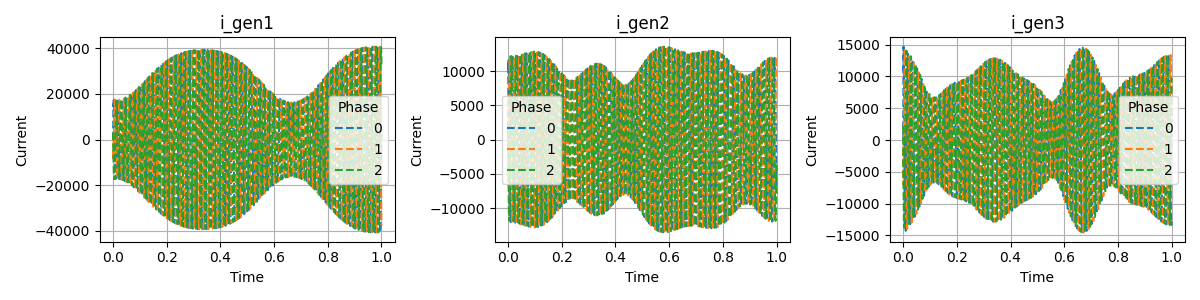

In [6]:

gen_vars = {
    'i_gen1': ['i_gen1_0', 'i_gen1_1', 'i_gen1_2'],
    'i_gen2': ['i_gen2_0', 'i_gen2_1', 'i_gen2_2'],
    'i_gen3': ['i_gen3_0', 'i_gen3_1', 'i_gen3_2'],
}




dataframes = [df1]
titles = ['Sim']

fig, axes = plt.subplots(1, 3, figsize=(12, 3))  # 1 row, 3 columns

df = dataframes[0]  # Since you only have one dataframe

for ax, (gen_name, var_list) in zip(axes, gen_vars.items()):
    for var in var_list:
        ax.plot(df['time'].values, df[var].values, linestyle="--", label=var.split('_')[-1])
    ax.set_title(gen_name)
    ax.set_xlabel('Time')
    ax.set_ylabel('Current')
    ax.grid(True)
    ax.legend(title="Phase")

plt.tight_layout()
plt.show()

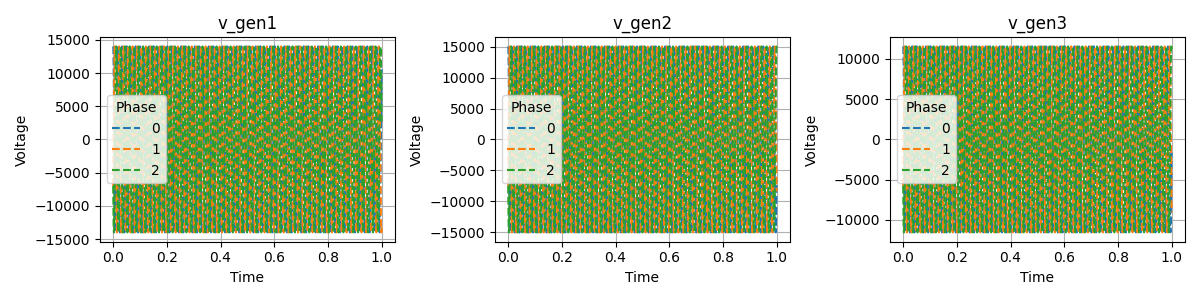

In [7]:

gen_vars = {
    'v_gen1': ['v_gen1_0', 'v_gen1_1', 'v_gen1_2'],
    'v_gen2': ['v_gen2_0', 'v_gen2_1', 'v_gen2_2'],
    'v_gen3': ['v_gen3_0', 'v_gen3_1', 'v_gen3_2'],
}

dataframes = [df1]
titles = ['Sim']

fig, axes = plt.subplots(1, 3, figsize=(12, 3))  # 1 row, 3 columns

df = dataframes[0]  # Since you only have one dataframe

for ax, (gen_name, var_list) in zip(axes, gen_vars.items()):
    for var in var_list:
        ax.plot(df['time'].values, df[var].values, linestyle="--", label=var.split('_')[-1])
    ax.set_title(gen_name)
    ax.set_xlabel('Time')
    ax.set_ylabel('Voltage')
    ax.grid(True)
    ax.legend(title="Phase")

plt.tight_layout()
plt.show()